In [1]:
# @title 1. Install dependencies (run once)
!pip install -q transformers torch yfinance scikit-learn pandas numpy matplotlib seaborn ipywidgets google-genai groq
print("Dependencies installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 129.8 MB/s eta 0:00:00
Dependencies installed.


In [2]:
# @title 2. Imports, device & efficiency note
import re, json, warnings, os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

try:
    import torch
    DEVICE = 0 if torch.cuda.is_available() else -1
    print("Torch:", torch.__version__, "| GPU:", torch.cuda.is_available())
except Exception as e:
    DEVICE = -1; print("CPU-only:", e)

# Efficiency principles used throughout:
#  (1) SLM pipelines are loaded ONCE and reused for every stock.
#  (2) Sentiment + topic inference are BATCHED (one call per stock's headlines).
#  (3) Price data & features are CACHED so the feedback loop recomputes instantly.

Torch: 2.11.0+cu128 | GPU: True


## Module 1 — Preprocessing & Normalization
Text pipeline (clean news) + time-series pipeline (engineer returns / MA / volatility / RSI, then MinMax-normalize).

In [3]:
# @title 1. Preprocessing utilities
class TextPreprocessor:
    def __init__(self):
        self.url_pat  = re.compile(r'https?://\S+|www\.\S+')
        self.html_pat = re.compile(r'<.*?>')
    def clean(self, text):
        if not isinstance(text, str) or not text.strip(): return ""
        text = text.lower()
        text = self.url_pat.sub(' ', text); text = self.html_pat.sub(' ', text)
        text = re.sub(r'[^a-z0-9\s.,%$()-]', ' ', text)
        return re.sub(r'\s+', ' ', text).strip()
tp = TextPreprocessor()

def add_technical_features(df):
    df = df.copy()
    df["return"]     = df["Close"].pct_change()
    df["ma7"]        = df["Close"].rolling(7).mean()
    df["ma21"]       = df["Close"].rolling(21).mean()
    df["volatility"] = df["return"].rolling(14).std()
    delta = df["Close"].diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    rs    = gain / loss.replace(0, np.nan)
    df["rsi"] = (100 - 100/(1+rs)).fillna(50)
    return df.dropna()

def normalize_features(df, cols):
    sc = MinMaxScaler(); out = df.copy()
    out[cols] = sc.fit_transform(out[cols]); return out, sc

print("Preprocessing utilities ready.")

Preprocessing utilities ready.


## Module 2 + 3 — SLM Sentiment & Zero-shot News Categorization (loaded once, called in batches)
Three independently-trained small sentiment models, loaded once and reused for every headline — this is the "3 SLMs" side of the Module 8 comparison:
- `ProsusAI/finbert` (~110M) — the canonical finance-tuned BERT.
- `yiyanghkust/finbert-tone` (~110M) — a second, independently fine-tuned finance BERT.
- `mrm8488/distilroberta-finetuned-financial-news-sentiment-analysis` (~82M) — a distilled model, used as the fast **primary** SLM that actually drives the live trading decision downstream.

Topics: zero-shot `distilbert-base-uncased-mnli` (~66M) over *elections / budget / monetary policy / corporate earnings / regulation / global markets* — shared across all three sentiment models, since categorisation is a separate task from sentiment scoring.

In [4]:
# @title 2+3. Load 3 SLM sentiment pipelines + shared zero-shot topic model (batched)
from transformers import pipeline

CATEGORIES = ["elections","budget","monetary policy",
              "corporate earnings","regulation","global markets"]

# Three independently-trained small finance-sentiment models -- this is the "3 SLMs" side
# of the Module 8 head-to-head. PRIMARY_SLM is the one that actually drives the live
# trading decision in Module 5 (kept fast); the other two exist for the comparison.
SLM_SENTIMENT_MODELS = {
    "FinBERT":               "ProsusAI/finbert",
    "FinBERT-Tone":          "yiyanghkust/finbert-tone",
    "DistilRoBERTa-FinNews": "mrm8488/distilroberta-finetuned-financial-news-sentiment-analysis",
}
PRIMARY_SLM = "DistilRoBERTa-FinNews"

sentiment_pipes = {}
for _name, _model_id in SLM_SENTIMENT_MODELS.items():
    try:
        sentiment_pipes[_name] = pipeline("sentiment-analysis", model=_model_id, device=DEVICE)
        print(f"SLM loaded: {_name} ({_model_id}).")
    except Exception as e:
        print(f"[warn] SLM '{_name}' unavailable, it will be skipped in comparisons. ({str(e)[:80]})")

zsl_pipe = None
try:
    zsl_pipe = pipeline("zero-shot-classification",
        model="typeform/distilbert-base-uncased-mnli", device=DEVICE)
    print("Zero-shot topic SLM loaded.")
except Exception as e:
    print(f"[warn] zero-shot topic SLM unavailable -> keyword fallback. ({str(e)[:60]})")

# Last-resort fallbacks kick in only if a *model itself* fails to load (e.g. no internet
# to Hugging Face Hub) -- an infra-availability guard, never a stand-in for real news data.
_POS = {"surge","gain","gains","profit","beats","beat","up","rally","rallies","record","growth","strong","rises","wins","buyback","expands","jumps"}
_NEG = {"fall","falls","loss","losses","miss","misses","down","slump","slumps","cut","cuts","weak","fraud","penalty","decline","slows","pressure","probe","worries"}
_KW = {"elections":["election","vote","poll","ballot","campaign","result"],
       "budget":["budget","fiscal","tax","subsidy","capex","deficit","infrastructure","infra"],
       "monetary policy":["rbi","repo","rate","inflation","mpc","liquidity","fed"],
       "corporate earnings":["profit","revenue","earnings","results","margin","dividend","deal","contract","subscribers","loan","nim","buyback"],
       "regulation":["sebi","probe","regulator","compliance","penalty","ban","disclosure","norms"],
       "global markets":["crude","oil","dollar","global","china","us ","rupee","dow","nasdaq"]}

def _lex_sent(c):
    toks=set(c.split()); p,n=len(toks&_POS),len(toks&_NEG)
    return 0.0 if p==n else (p-n)/max(p+n,1)
def _kw_cat(c):
    toks=set(c.split()); best,bs="global markets",0
    for cat,kw in _KW.items():
        sc=len(toks&set(kw))
        if sc>bs: best,bs=cat,sc
    return best

def sentiment_batch_for(name, texts):
    """Score `texts` with one named SLM. A secondary (non-primary) SLM that failed to
    load returns None per item -- it is skipped cleanly in comparisons rather than
    silently mislabeling a keyword heuristic as that model. Only the PRIMARY_SLM falls
    back to a lexicon, so the live decision engine below still runs end to end."""
    if not texts: return []
    cl = [tp.clean(t) for t in texts]
    pipe = sentiment_pipes.get(name)
    if pipe is None:
        if name == PRIMARY_SLM:
            return [_lex_sent(c) for c in cl]
        return [None] * len(cl)
    res = pipe([c[:512] if c else "neutral" for c in cl])
    out = []
    for c, r in zip(cl, res):
        if not c: out.append(0.0); continue
        lab = r["label"].lower(); s = float(r["score"])
        out.append(s if ("pos" in lab or lab.endswith("2"))
                   else (-s if ("neg" in lab or lab.endswith("0")) else 0.0))
    return out

def sentiment_batch(texts):
    """Convenience wrapper: the PRIMARY SLM only, used by the live decision engine (Module 5)."""
    return sentiment_batch_for(PRIMARY_SLM, texts)

def categorize_batch(texts):
    if not texts: return []
    cl=[tp.clean(t) for t in texts]
    if zsl_pipe is not None:
        res=zsl_pipe([c if c else "general market" for c in cl], CATEGORIES, multi_label=False)
        if isinstance(res, dict): res=[res]
        return [r["labels"][0] for r in res]
    return [_kw_cat(c) for c in cl]

# smoke test -- run all 3 SLMs + the shared topic model on the same 3 sample headlines
_t=["TCS wins large cloud deal","Government raises infra capex in budget","SEBI penalty on bank for compliance lapse"]
for _name in SLM_SENTIMENT_MODELS:
    _scores = [round(x,2) if x is not None else None for x in sentiment_batch_for(_name, _t)]
    print(f"{_name:22s} -> {_scores}")
print(f"{'topics':22s} -> {categorize_batch(_t)}")

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/258 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Zero-shot topic SLM loaded.
FinBERT                -> [0.0, 0.0, -0.89]
FinBERT-Tone           -> [None, None, None]
DistilRoBERTa-FinNews  -> [1.0, 0.99, -0.92]
topics                 -> ['corporate earnings', 'budget', 'regulation']


## Module 4 — Configuration: 5-stock portfolio + REAL, LIVE news only
Each ticker's headlines are pulled live from Google News RSS (default, no key needed) or NewsAPI.org (if a `NEWSAPI_KEY` is set — see the cell below for how to add it as a Colab secret). **There is no synthetic/fabricated headline fallback anywhere in this notebook.** If real, live headlines can't be found for a stock after retrying across sources, query variants and time windows, the cell raises an error explaining why and the notebook stops — it never substitutes placeholder sentiment.

In [5]:
# @title 4. Portfolio + REAL, LIVE news only (Google News RSS + optional NewsAPI.org -- no synthetic fallback)
import time, urllib.request, urllib.parse, email.utils as eut
import xml.etree.ElementTree as ET

TICKERS = ["RELIANCE.NS","TCS.NS","HDFCBANK.NS","INFY.NS","ICICIBANK.NS"]

# Google News RSS needs plain company names, not ticker symbols. Appending
# "stock" biases results toward financial/market news over general coverage.
COMPANY_QUERY = {
    "RELIANCE.NS":  "Reliance Industries stock",
    "TCS.NS":       "TCS stock",
    "HDFCBANK.NS":  "HDFC Bank stock",
    "INFY.NS":      "Infosys stock",
    "ICICIBANK.NS": "ICICI Bank stock",
}

# Optional: a free NewsAPI.org key (https://newsapi.org/register) gives cleaner,
# structured metadata -- reliable publish timestamps and source names -- than scraping
# Google News RSS, so it's worth adding. In Colab: click the key icon ("Secrets") in
# the left sidebar -> "Add new secret" -> name it NEWSAPI_KEY -> paste the key ->
# toggle "Notebook access" on. It is NOT required: Google News RSS needs no key at all
# and is the default, so the notebook runs unmodified for anyone without one.
NEWSAPI_KEY = os.environ.get("NEWSAPI_KEY", "")
if not NEWSAPI_KEY:
    try:
        from google.colab import userdata as _userdata
        NEWSAPI_KEY = _userdata.get("NEWSAPI_KEY") or ""
    except Exception:
        pass

def _clean_headline(title, source):
    if source and title.endswith(" - " + source):
        title = title[: -(len(source) + 3)]
    return title.strip()

def _parse_pubdate(raw):
    """Parse either RFC-822 (Google News RSS) or ISO-8601 (NewsAPI) publish timestamps
    into a UTC pandas Timestamp + display string. This is the ARTICLE's publish time,
    not the fetch time. A headline with no parseable date keeps its raw string rather
    than being dropped or getting a made-up time."""
    if not raw:
        return None, "unknown"
    for parser in (eut.parsedate_to_datetime, pd.Timestamp):
        try:
            dt = parser(raw)
            ts = pd.Timestamp(dt)
            ts = ts.tz_localize("UTC") if ts.tzinfo is None else ts.tz_convert("UTC")
            return ts, ts.strftime("%Y-%m-%d %H:%M UTC")
        except Exception:
            continue
    return None, str(raw)[:20]

def fetch_google_news(query, max_items=6, window_days=14, retries=3, timeout=10):
    """Real, live headlines from the public Google News RSS search feed. No API key required."""
    q = urllib.parse.quote(f"{query} when:{window_days}d")
    url = f"https://news.google.com/rss/search?q={q}&hl=en-IN&gl=IN&ceid=IN:en"
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    last_err = None
    for attempt in range(retries):
        try:
            with urllib.request.urlopen(req, timeout=timeout) as resp:
                raw = resp.read()
            root = ET.fromstring(raw)
            items, seen = [], set()
            for item in root.findall(".//item"):
                title = (item.findtext("title") or "").strip()
                src   = (item.findtext("source") or "").strip()
                link  = (item.findtext("link") or "").strip()
                pub   = (item.findtext("pubDate") or "").strip()
                title = _clean_headline(title, src)
                key = title.lower()
                if title and key not in seen:
                    seen.add(key)
                    pub_ts, pub_str = _parse_pubdate(pub)
                    items.append({"headline": title, "source": src or "Google News", "link": link,
                                  "published": pub, "published_dt": pub_ts, "published_str": pub_str})
                if len(items) >= max_items:
                    break
            return items
        except Exception as e:
            last_err = e
            if attempt < retries - 1:
                time.sleep(1.5 * (attempt + 1))
    print(f"[warn] Google News RSS fetch failed for '{query}': {str(last_err)[:100]}")
    return []

def fetch_newsapi(query, max_items=6):
    """Alternative real source: NewsAPI.org (needs NEWSAPI_KEY)."""
    params = urllib.parse.urlencode({
        "q": query, "language": "en", "sortBy": "publishedAt",
        "pageSize": max_items, "apiKey": NEWSAPI_KEY,
    })
    url = f"https://newsapi.org/v2/everything?{params}"
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    try:
        with urllib.request.urlopen(req, timeout=10) as resp:
            data = json.loads(resp.read())
        items = []
        for a in data.get("articles", []):
            if not a.get("title"):
                continue
            pub = a.get("publishedAt", "")
            pub_ts, pub_str = _parse_pubdate(pub)
            items.append({"headline": a["title"], "source": (a.get("source") or {}).get("name","NewsAPI"),
                         "link": a.get("url",""), "published": pub, "published_dt": pub_ts, "published_str": pub_str})
        return items[:max_items]
    except Exception as e:
        print(f"[warn] NewsAPI fetch failed for '{query}': {str(e)[:100]}")
        return []

def fetch_real_news(ticker):
    """Fetch REAL headlines for `ticker`, trying multiple real sources / query variants /
    time windows before giving up -- but NEVER falling back to synthetic headlines.
    Returns (items, attempts_log) so a failure can be explained, not just reported."""
    company = COMPANY_QUERY[ticker]
    bare    = company.replace(" stock", "")
    attempts = []

    if NEWSAPI_KEY:
        items = fetch_newsapi(company, max_items=6); attempts.append(f"NewsAPI.org('{company}')")
        if not items:
            items = fetch_google_news(company, max_items=6, window_days=14); attempts.append(f"Google News RSS('{company}', 14d)")
    else:
        items = fetch_google_news(company, max_items=6, window_days=14); attempts.append(f"Google News RSS('{company}', 14d)")

    if not items:
        items = fetch_google_news(company, max_items=6, window_days=45); attempts.append(f"Google News RSS('{company}', 45d)")
    if not items:
        items = fetch_google_news(bare, max_items=6, window_days=45); attempts.append(f"Google News RSS('{bare}', 45d)")
    return items, attempts

NEWS_META, NEWS_BANK, _fetch_log = {}, {}, {}
for t in TICKERS:
    items, attempts = fetch_real_news(t)
    NEWS_META[t] = items
    NEWS_BANK[t] = [it["headline"] for it in items]
    _fetch_log[t] = attempts
    time.sleep(0.4)  # be polite to the free feeds

_total = sum(len(v) for v in NEWS_BANK.values())
_empty = [t for t in TICKERS if not NEWS_BANK[t]]

if _empty:
    _detail = "\n".join(f"  - {t}: tried {' -> then '.join(_fetch_log[t])}, all returned 0 real headlines" for t in _empty)
    raise RuntimeError(
        "REAL NEWS UNAVAILABLE -- stopping rather than substituting fabricated headlines.\n"
        f"Could not fetch any live headlines for {len(_empty)}/{len(TICKERS)} stock(s) after "
        f"trying every real source this notebook supports:\n{_detail}\n\n"
        "Likely causes: no internet access from this Colab runtime, Google News RSS "
        "temporarily rate-limiting Colab's shared IP range, or an invalid/expired NEWSAPI_KEY.\n"
        "What to try: (1) re-run this cell -- transient rate limits usually clear within a "
        "minute or two, (2) add a free NewsAPI.org key as the NEWSAPI_KEY Colab secret for a "
        "second real source, (3) Runtime -> Restart session if the runtime's network looks stuck."
    )

print(f"{len(TICKERS)} stocks, {_total} REAL live headlines fetched. Sources used per stock:")
for t in TICKERS:
    srcs = ", ".join(sorted(set(it["source"] for it in NEWS_META[t]))) or "-"
    print(f"  {t}: {len(NEWS_BANK[t])} headlines from [{srcs}]")

5 stocks, 30 REAL live headlines fetched. Sources used per stock:
  RELIANCE.NS: 6 headlines from [BusinessLine, PRNewswire, The Times of India, iTnews]
  TCS.NS: 6 headlines from [BusinessLine, NewsX, The Times of India, The Tribune India]
  HDFCBANK.NS: 6 headlines from [BusinessLine, The Times of India]
  INFY.NS: 6 headlines from [Business Insider, Livemint, The Times of India]
  ICICIBANK.NS: 6 headlines from [BusinessLine, The Times of India, The Tribune India]


In [6]:
# @title 4b. Fetch + cache price data for all stocks (live -> synthetic fallback)
def generate_synthetic_prices(ticker, n=180):
    rng = np.random.default_rng(abs(hash(ticker)) % (2**32))
    dates = pd.bdate_range(end=pd.Timestamp.today().normalize(), periods=n)
    n = len(dates)
    rets  = rng.normal(0.0004, 0.014, n)
    base  = 400 + abs(hash(ticker)) % 2200
    price = base * np.exp(np.cumsum(rets))
    vol   = rng.integers(1e5, 5e6, n)
    return pd.DataFrame({"Close": price, "Volume": vol}, index=dates)

def fetch_one(ticker, period="6mo"):
    try:
        import yfinance as yf
        df = yf.download(ticker, period=period, progress=False, auto_adjust=True)
        if df is None or df.empty: raise ValueError("empty")
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)
        df = df[["Close","Volume"]].dropna()
        if len(df) < 40: raise ValueError("few rows")
        return df, "live"
    except Exception:
        return generate_synthetic_prices(ticker), "synthetic"

PRICE_DATA, FEATURES, sources = {}, {}, {}
for t in TICKERS:
    raw, src = fetch_one(t)
    PRICE_DATA[t] = raw; FEATURES[t] = add_technical_features(raw); sources[t] = src
print("Data sources:", sources)
print("Rows per stock:", {t: len(f) for t,f in FEATURES.items()})

Data sources: {'RELIANCE.NS': 'live', 'TCS.NS': 'live', 'HDFCBANK.NS': 'live', 'INFY.NS': 'live', 'ICICIBANK.NS': 'live'}
Rows per stock: {'RELIANCE.NS': 104, 'TCS.NS': 104, 'HDFCBANK.NS': 104, 'INFY.NS': 104, 'ICICIBANK.NS': 104}


## Module 5 — Multi-source fusion & the portfolio loop
For every stock: blend the **technical signal** (RSI + MA momentum) with **topic-weighted SLM sentiment**, using a blend weight `w_sent` that the feedback loop controls. Output a `BUY / HOLD / SELL` with a confidence score.

In [7]:
# @title 5. Decision engine + portfolio loop
CATEGORY_WEIGHT = {"elections":1.3,"budget":1.4,"monetary policy":1.5,
                   "corporate earnings":1.2,"regulation":1.1,"global markets":1.0}

def technical_signal(row):
    s = 0.0
    if row["rsi"] < 35:   s += 0.5
    elif row["rsi"] > 65: s -= 0.5
    s += np.tanh((row["ma7"]-row["ma21"]) / row["ma21"] * 20) * 0.5
    return float(np.clip(s, -1, 1))

# Pre-compute news signals ONCE per stock (batched) and cache them.
_NEWS_COLS = ["ticker", "headline", "published", "source", "sentiment", "topic", "weighted"]
NEWS_SIGNALS = {}
for t in TICKERS:
    heads = NEWS_BANK[t]
    meta  = NEWS_META[t]
    sents = sentiment_batch(heads)
    cats  = categorize_batch(heads)
    rows  = []
    for h, m, s, c in zip(heads, meta, sents, cats):
        cw = CATEGORY_WEIGHT.get(c, 1.0)
        rows.append({"ticker": t, "headline": h, "published": m["published_str"], "source": m["source"],
                     "sentiment": round(s,3), "topic": c, "weighted": round(float(np.clip(s*cw,-1,1)),3)})
    NEWS_SIGNALS[t] = pd.DataFrame(rows, columns=_NEWS_COLS)

def analyze_stock(ticker, w_sent):
    feat_row = FEATURES[ticker].iloc[-1]
    tech_s   = technical_signal(feat_row)
    nd       = NEWS_SIGNALS[ticker]
    # Module 4 guarantees every ticker has >=1 real headline (it hard-stops otherwise),
    # so this length guard is just defensive -- it is never a stand-in for fabricated news.
    sent_s   = float(np.clip(nd["weighted"].mean(), -1, 1)) if len(nd) else 0.0
    score    = (1 - w_sent)*tech_s + w_sent*sent_s
    action   = "BUY" if score > 0.25 else "SELL" if score < -0.25 else "HOLD"
    conf     = round(min(1.0, abs(score)/0.5), 2)
    return {"ticker": ticker, "price": round(float(feat_row["Close"]),2),
            "rsi": round(float(feat_row["rsi"]),1), "technical": round(tech_s,3),
            "sentiment": round(sent_s,3), "score": round(float(score),3),
            "action": action, "confidence": conf}

def run_portfolio(w_sent):
    return pd.DataFrame([analyze_stock(t, w_sent) for t in TICKERS]).set_index("ticker")

portfolio = run_portfolio(0.5)
portfolio

,price,rsi,technical,sentiment,score,action,confidence
ticker,,,,,,,
RELIANCE.NS,"1,296.600",43.100,-0.098,0.158,0.030,HOLD,0.060
TCS.NS,"2,201.000",61.500,0.154,0.000,0.077,HOLD,0.150
HDFCBANK.NS,808.300,55.900,0.142,0.167,0.154,HOLD,0.310
INFY.NS,"1,082.400",58.000,0.191,0.224,0.207,HOLD,0.410
ICICIBANK.NS,"1,418.200",60.100,0.103,-0.166,-0.031,HOLD,0.060


## Clear table 1 — Colour-coded portfolio summary

In [8]:
# @title T1. Styled portfolio summary
def style_portfolio(df):
    cmap = {"BUY":"#1b7837","SELL":"#b2182b","HOLD":"#666"}
    sty = (df.style
             .format({"price":"{:,.2f}","rsi":"{:.1f}","technical":"{:+.3f}",
                      "sentiment":"{:+.3f}","score":"{:+.3f}","confidence":"{:.0%}"})
             .background_gradient(subset=["score"], cmap="RdYlGn", vmin=-1, vmax=1)
             .background_gradient(subset=["rsi"], cmap="coolwarm", vmin=0, vmax=100)
             .set_caption("Portfolio recommendations (w_sent = 0.50)"))
    f = (lambda v: f"color:{cmap.get(v,'#000')}; font-weight:700")
    sty = sty.map(f, subset=["action"]) if hasattr(sty,"map") else sty.applymap(f, subset=["action"])
    return sty

style_portfolio(portfolio)

,price,rsi,technical,sentiment,score,action,confidence
ticker,,,,,,,
RELIANCE.NS,"1,296.60",43.1,-0.098,+0.158,+0.030,HOLD,6%
TCS.NS,"2,201.00",61.5,+0.154,+0.000,+0.077,HOLD,15%
HDFCBANK.NS,808.30,55.9,+0.142,+0.167,+0.154,HOLD,31%
INFY.NS,"1,082.40",58.0,+0.191,+0.224,+0.207,HOLD,41%
ICICIBANK.NS,"1,418.20",60.1,+0.103,-0.166,-0.031,HOLD,6%


## Clear table 2 — Per-stock news breakdown (sentiment × topic)

In [9]:
# @title T2. News breakdown table
news_all = pd.concat(NEWS_SIGNALS.values(), ignore_index=True)
def style_news(df):
    sty = (df[["ticker","headline","published","source","sentiment","topic","weighted"]]
            .style
            .format({"sentiment":"{:+.2f}","weighted":"{:+.2f}"})
            .background_gradient(subset=["weighted"], cmap="RdYlGn", vmin=-1, vmax=1)
            .set_caption(f"Topic-weighted sentiment per headline ({PRIMARY_SLM}) -- real headlines, "
                         "with publish time & source so every row traces back to a real article"))
    return sty
style_news(news_all)

,ticker,headline,published,source,sentiment,topic,weighted
0,RELIANCE.NS,"Sensex today | Stock Market Highlights: Sensex closed at 77,185.43; Nifty 50 was to 24,078.50",2026-07-15 10:58 UTC,BusinessLine,+0.00,global markets,+0.00
1,RELIANCE.NS,"Explained: Why is stock market rising today even as Iran-US war escalates, oil prices cross $85",2026-07-15 06:56 UTC,The Times of India,+1.00,global markets,+1.00
2,RELIANCE.NS,"Sensex jumps over 500 points, Nifty above 24,200 led by financials; Mideast tensions cap gains",2026-07-15 04:05 UTC,The Times of India,+1.00,corporate earnings,+1.00
3,RELIANCE.NS,Insilico Medicine and Bora Pharmaceuticals Announce Strategic Alliance for AI-Driven Drug Discovery and Development,2026-07-15 00:00 UTC,PRNewswire,+0.95,global markets,+0.95
4,RELIANCE.NS,IBM warns AI boom squeezing software budgets,2026-07-14 20:34 UTC,iTnews,-1.00,budget,-1.00
5,RELIANCE.NS,IBM warns AI boom squeezing software budgets,2026-07-14 20:34 UTC,iTnews,-1.00,budget,-1.00
6,TCS.NS,"Sensex rises 130 points, Nifty closes above 24,050 led by banking, oil & gas stocks - The Tribune",2026-07-15 11:48 UTC,The Tribune India,+1.00,global markets,+1.00
7,TCS.NS,CSR Conclave to debate next phase of corporate social responsibility,2026-07-15 11:26 UTC,BusinessLine,+0.00,regulation,+0.00
8,TCS.NS,"Sensex today | Stock Market Highlights: Sensex closed at 77,185.43; Nifty 50 was to 24,078.50",2026-07-15 10:58 UTC,BusinessLine,+0.00,global markets,+0.00
9,TCS.NS,"IBM's 25% Stock Crash Jolts Indian IT Stocks: Should TCS, Infosys And Wipro Investors Worry?",2026-07-15 09:48 UTC,NewsX,-1.00,global markets,-1.00


## Analytics dashboard
Four clear views: price trends, a signal heatmap, the action ranking, and the topic mix driving sentiment.

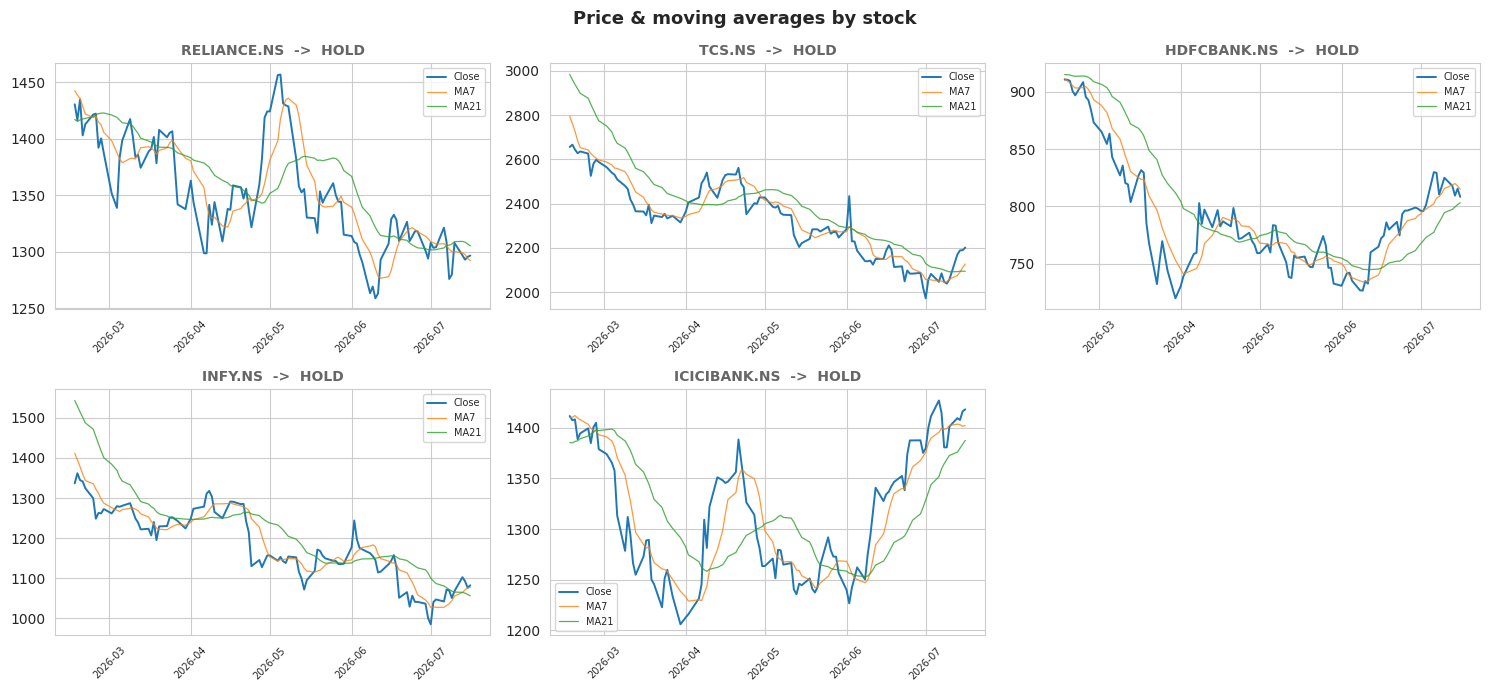

In [10]:
# @title G1. Small-multiple price + moving-average charts
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
axes = axes.ravel()
for i, t in enumerate(TICKERS):
    f = FEATURES[t]; ax = axes[i]
    ax.plot(f.index, f["Close"], lw=1.4, label="Close")
    ax.plot(f.index, f["ma7"],  lw=.9, alpha=.8, label="MA7")
    ax.plot(f.index, f["ma21"], lw=.9, alpha=.8, label="MA21")
    act = portfolio.loc[t,"action"]
    col = {"BUY":"#1b7837","SELL":"#b2182b","HOLD":"#666"}[act]
    ax.set_title(f"{t}  ->  {act}", color=col, fontweight="bold", fontsize=10)
    ax.tick_params(axis="x", rotation=45, labelsize=7); ax.legend(fontsize=7)
axes[-1].axis("off")
plt.suptitle("Price & moving averages by stock", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

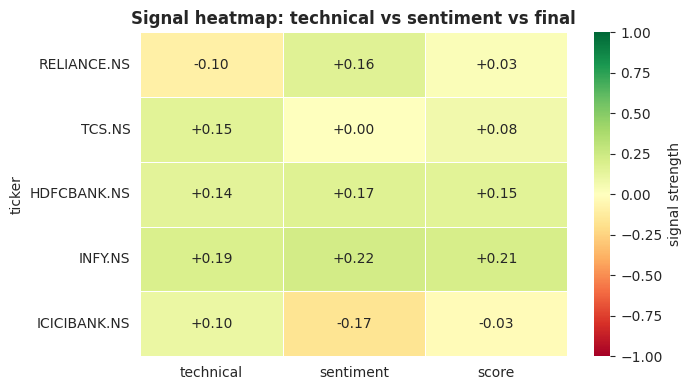

In [11]:
# @title G2. Signal heatmap (stocks x signal components)
hm = portfolio[["technical","sentiment","score"]]
plt.figure(figsize=(7, 4))
sns.heatmap(hm, annot=True, fmt="+.2f", cmap="RdYlGn", center=0, vmin=-1, vmax=1,
            linewidths=.5, cbar_kws={"label":"signal strength"})
plt.title("Signal heatmap: technical vs sentiment vs final", fontweight="bold")
plt.tight_layout(); plt.show()

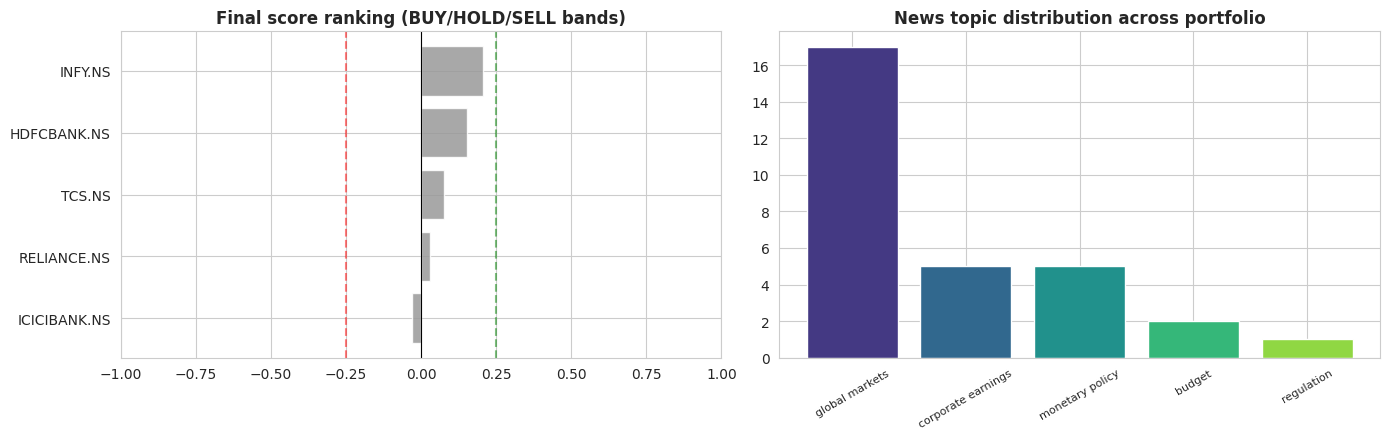

In [12]:
# @title G3. Final-score ranking + G4. Topic distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

ranked = portfolio.sort_values("score")
colors = [{"BUY":"#1b7837","SELL":"#b2182b","HOLD":"#999"}[a] for a in ranked["action"]]
ax1.barh(ranked.index, ranked["score"], color=colors, alpha=.85)
ax1.axvline(0.25, ls="--", color="green", alpha=.5); ax1.axvline(-0.25, ls="--", color="red", alpha=.5)
ax1.axvline(0, color="k", lw=.8); ax1.set_xlim(-1, 1)
ax1.set_title("Final score ranking (BUY/HOLD/SELL bands)", fontweight="bold")

topic_counts = news_all["topic"].value_counts()
ax2.bar(topic_counts.index, topic_counts.values, color=sns.color_palette("viridis", len(topic_counts)))
ax2.set_title("News topic distribution across portfolio", fontweight="bold")
ax2.tick_params(axis="x", rotation=30, labelsize=8)
plt.tight_layout(); plt.show()

## Module 6 — User feedback (adaptive) + product-style panel
Rate a recommendation 👍/👎. The store logs it, adapts `w_sent` (how much to trust news vs. technicals), and the **whole portfolio re-ranks** — exactly how a deployed product would learn from users.

In [13]:
# @title 6a. Adaptive feedback store
class FeedbackStore:
    def __init__(self, path="feedback.json"):
        self.path=path; self.records=[]; self.w_sent=0.5
        if os.path.exists(path):
            try: self.records=json.load(open(path))
            except Exception: self.records=[]
    def add(self, ticker, predicted, helpful):
        self.records.append({"ticker":ticker,"predicted":predicted,"helpful":bool(helpful)})
        recent=self.records[-20:]
        rate=sum(r["helpful"] for r in recent)/len(recent)
        self.w_sent=float(np.clip(0.2+0.6*rate, 0.2, 0.8)); self.save(); return self.w_sent
    def save(self):
        with open(self.path,"w") as f: json.dump(self.records,f,indent=2)
    def stats(self):
        n=len(self.records); h=sum(r["helpful"] for r in self.records)
        return n, h, self.w_sent
feedback = FeedbackStore()
print("Feedback store ready. w_sent =", feedback.w_sent)

Feedback store ready. w_sent = 0.5


In [14]:
# @title 6b. Product-style interactive recommendation + feedback panel
import ipywidgets as widgets
from IPython.display import display, HTML
try:
    from google.colab import output as _co; _co.enable_custom_widget_manager()
except Exception: pass

BADGE={"BUY":"#1b7837","SELL":"#b2182b","HOLD":"#666"}
def card_html(ticker, w_sent):
    r=analyze_stock(ticker, w_sent); col=BADGE[r["action"]]
    bar=int((r["score"]+1)/2*100)
    top=NEWS_SIGNALS[ticker].reindex(NEWS_SIGNALS[ticker]["weighted"].abs().sort_values(ascending=False).index).head(2)
    news_li="".join(
        f"<li>{x.headline} <i>({x.topic}, {x.weighted:+.2f})</i>"
        f"<br><span style='color:#999;font-size:11px'>{x.published} &middot; {x.source}</span></li>"
        for x in top.itertuples())
    return f"""
    <div style='font-family:system-ui;border:1px solid #e0e0e0;border-radius:12px;
                padding:16px 18px;max-width:520px;box-shadow:0 2px 6px rgba(0,0,0,.06)'>
      <div style='display:flex;justify-content:space-between;align-items:center'>
        <span style='font-size:18px;font-weight:700'>{ticker}</span>
        <span style='background:{col};color:#fff;padding:4px 14px;border-radius:20px;
                     font-weight:700;font-size:14px'>{r['action']}</span></div>
      <div style='margin:10px 0;color:#444;font-size:13px'>
        Price ₹{r['price']:,.2f} &nbsp;|&nbsp; RSI {r['rsi']:.0f} &nbsp;|&nbsp;
        technical {r['technical']:+.2f} &nbsp;|&nbsp; sentiment {r['sentiment']:+.2f}</div>
      <div style='background:#eee;border-radius:6px;height:10px;overflow:hidden'>
        <div style='width:{bar}%;height:10px;background:{col}'></div></div>
      <div style='font-size:12px;color:#666;margin-top:4px'>score {r['score']:+.2f} · confidence {r['confidence']:.0%}</div>
      <ul style='font-size:12px;color:#555;margin:10px 0 0 0;padding-left:18px'>{news_li}</ul>
    </div>"""

dropdown = widgets.Dropdown(options=TICKERS, description="Stock:")
card_out = widgets.Output(); table_out = widgets.Output()
metrics  = widgets.HTML()
up   = widgets.Button(description="👍 Helpful", button_style="success")
down = widgets.Button(description="👎 Not helpful", button_style="danger")
recompute = widgets.Button(description="↻ Recompute portfolio", button_style="info")

def refresh_card(*_):
    card_out.clear_output(wait=True)
    with card_out: display(HTML(card_html(dropdown.value, feedback.w_sent)))
def refresh_metrics():
    n,h,w=feedback.stats(); rate=(h/n*100) if n else 0
    wbar=int((w-0.2)/0.6*100)
    metrics.value=(f"<div style='font-family:system-ui;font-size:13px'>"
       f"<b>{n}</b> ratings · <b>{h}</b> helpful (<b>{rate:.0f}%</b>) &nbsp;|&nbsp; "
       f"sentiment weight <b>{w:.2f}</b>"
       f"<div style='background:#eee;border-radius:6px;height:8px;width:240px;margin-top:4px'>"
       f"<div style='width:{wbar}%;height:8px;background:#3b82f6;border-radius:6px'></div></div></div>")
def refresh_table():
    table_out.clear_output(wait=True)
    with table_out: display(style_portfolio(run_portfolio(feedback.w_sent)))
def rate(helpful):
    r=analyze_stock(dropdown.value, feedback.w_sent)
    feedback.add(dropdown.value, r["action"], helpful)
    refresh_metrics(); refresh_card()

dropdown.observe(refresh_card, names="value")
up.on_click(lambda _: rate(True)); down.on_click(lambda _: rate(False))
recompute.on_click(lambda _: refresh_table())
refresh_card(); refresh_metrics(); refresh_table()

display(widgets.VBox([
    widgets.HTML("<h4 style='font-family:system-ui;margin:4px 0'>📈 Recommendation desk</h4>"),
    dropdown, card_out, widgets.HBox([up, down, recompute]), metrics,
    widgets.HTML("<hr><b style='font-family:system-ui'>Live portfolio (updates with feedback)</b>"),
    table_out]))

## Module 7 — Compact technical backtest (the "advanced" check)
Replays the technical signal historically: go long when signal > 0.25, short when < −0.25, flat otherwise; mark to the next day's return. Reports strategy vs. buy-&-hold and a directional hit-rate, plus an equity curve. *(Illustrative on synthetic data; meaningful on live history.)*

In [15]:
# @title 7a. Backtest table
def backtest(feat):
    sig = feat.apply(technical_signal, axis=1)
    pos = np.where(sig>0.25, 1, np.where(sig<-0.25, -1, 0))
    fwd = feat["Close"].pct_change().shift(-1).fillna(0).values
    strat = pos*fwd
    cum_strat = np.cumprod(1+strat)-1
    cum_bh    = np.cumprod(1+feat["return"].fillna(0).values)-1
    active = pos!=0
    hit = np.mean((strat>0)[active])*100 if active.any() else np.nan
    return cum_strat, cum_bh, {"strategy_%": round(cum_strat[-1]*100,2),
                              "buy_hold_%": round(cum_bh[-1]*100,2),
                              "hit_rate_%": (round(hit,1) if active.any() else np.nan),
                              "trades": int(active.sum())}
EQUITY={}; rows=[]
for t in TICKERS:
    cs, cb, m = backtest(FEATURES[t]); EQUITY[t]=(cs,cb)
    rows.append({"ticker":t, **m})
bt = pd.DataFrame(rows).set_index("ticker")
bt.style.format({"strategy_%":"{:+.2f}","buy_hold_%":"{:+.2f}","hit_rate_%":"{:.1f}"}) \
        .background_gradient(subset=["strategy_%"], cmap="RdYlGn", vmin=-30, vmax=30) \
        .set_caption("Technical-signal backtest vs buy-and-hold")

,strategy_%,buy_hold_%,hit_rate_%,trades
ticker,,,,
RELIANCE.NS,-1.12,-8.24,37.5,24
TCS.NS,+3.55,-16.68,42.3,26
HDFCBANK.NS,-0.46,-9.10,45.5,22
INFY.NS,-0.97,-19.23,50.0,30
ICICIBANK.NS,-3.23,+0.25,52.9,17


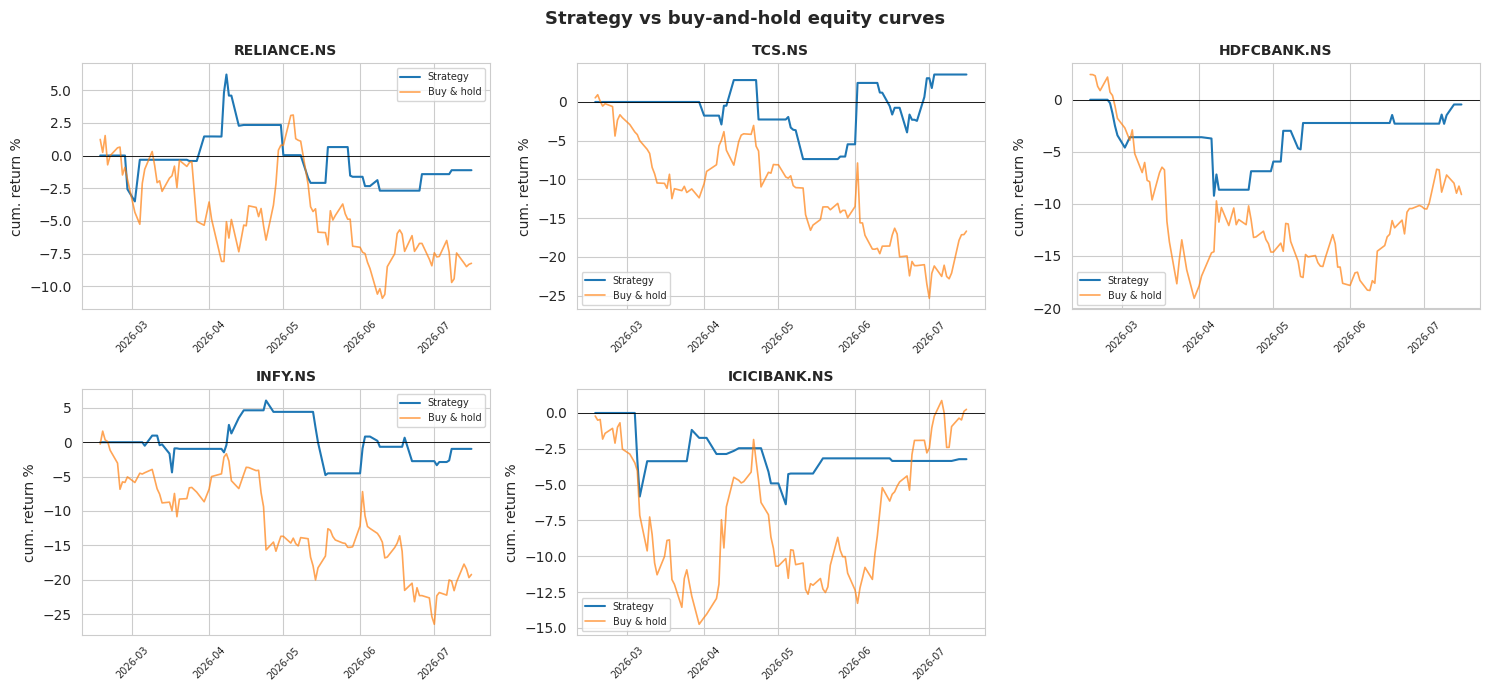

In [16]:
# @title 7b. Equity curves
fig, axes = plt.subplots(2, 3, figsize=(15, 7)); axes=axes.ravel()
for i,t in enumerate(TICKERS):
    cs, cb = EQUITY[t]; idx=FEATURES[t].index; ax=axes[i]
    ax.plot(idx, cs*100, label="Strategy", lw=1.5)
    ax.plot(idx, cb*100, label="Buy & hold", lw=1.2, alpha=.7)
    ax.axhline(0, color="k", lw=.6); ax.set_title(t, fontsize=10, fontweight="bold")
    ax.set_ylabel("cum. return %"); ax.tick_params(axis="x", rotation=45, labelsize=7); ax.legend(fontsize=7)
axes[-1].axis("off")
plt.suptitle("Strategy vs buy-and-hold equity curves", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

## Module 8 — SLM vs LLM comparison: 3 small models vs up to 3 free large models
The exact same **live** headlines fetched in Module 4 — same text, same timestamp, same source — are scored by every configured system side by side:
- **3 SLMs** (Module 2+3, run locally, already computed above): FinBERT, FinBERT-Tone, DistilRoBERTa-FinNews.
- **Up to 3 free LLM APIs**: Google Gemini, Groq (Llama 3.3 70B), and OpenRouter's free-models router. Each is optional — add whichever key(s) you have; the notebook uses whatever is configured and skips the rest cleanly with a message, never fabricating numbers for a system with no key.

Get free keys: [Gemini](https://aistudio.google.com/apikey) · [Groq](https://console.groq.com/keys) · [OpenRouter](https://openrouter.ai/keys). A DeepSeek option is also wired in (`DEEPSEEK_API_KEY`) for anyone who wants it, but note DeepSeek's API is **not actually free** anymore — see cell 8a for details and pricing.

Since there's no labeled ground truth for live headlines, "properly evaluated" here means the things that actually are measurable:
- **Agreement**: pairwise sentiment sign agreement %, and a full correlation matrix across every configured system
- **Decision impact**: does swapping the primary SLM's sentiment leg for another system's change the final BUY/HOLD/SELL call?
- **Cost & latency**: local SLM inference time vs. each LLM API's round-trip time, and token usage from each API's own response

Everything is visualised, not just tabulated: cells 8e-8f chart correlation, agreement, latency/throughput and token cost; cell 8g adds a 4-panel dashboard (sentiment distribution per system, headline coverage, a BUY/HOLD/SELL decision grid, and per-ticker LLM latency) so the whole comparison is readable at a glance.

In [17]:
# @title 8a. LLM provider setup -- Gemini, Groq, OpenRouter (free), optional DeepSeek (paid)
from google import genai
from google.genai import types as genai_types

def _get_secret(name):
    v = os.environ.get(name, "")
    if v: return v.strip()
    try:
        from google.colab import userdata as _ud
        v = _ud.get(name)
        return v.strip() if v else ""
    except Exception:
        return ""

def _get_key_list(base_name):
    """Supports one key (BASE_NAME), several (BASE_NAME_2, BASE_NAME_3, BASE_NAME_4) or a
    comma-separated BASE_NAMES secret -- so a rate-limited free key (e.g. Gemini's free-tier
    quota) can be backed up with another account's key purely via Colab secrets, no code change."""
    keys = []
    combined = _get_secret(base_name + "S")
    if combined:
        keys.extend(k.strip() for k in combined.split(",") if k.strip())
    for suffix in ["", "_2", "_3", "_4"]:
        v = _get_secret(base_name + suffix)
        if v and v not in keys:
            keys.append(v)
    return keys

GEMINI_KEYS     = _get_key_list("GEMINI_API_KEY")
GROQ_KEYS       = _get_key_list("GROQ_API_KEY")
OPENROUTER_KEYS = _get_key_list("OPENROUTER_API_KEY")
DEEPSEEK_KEYS   = _get_key_list("DEEPSEEK_API_KEY")

GEMINI_MODEL     = "gemini-3.5-flash"
GROQ_MODEL       = "llama-3.3-70b-versatile"
OPENROUTER_MODEL = "openrouter/free"   # OpenRouter's own router -- auto-picks whichever model is currently free
DEEPSEEK_MODEL   = "deepseek-v4-flash"

# Fix for the "429 - You exceeded your current quota" error: the previous version called a
# non-existent `gemini_client.interactions.create(...)` method (not part of the google-genai
# SDK) and, by leaving the model's "thinking" mode on its default, was spending a chunk of
# the free-tier's daily TOKEN quota on hidden reasoning tokens before ever answering -- on a
# 5-call-per-run workload that's a fast way to exhaust a free key. Fixed by (1) calling the
# real `client.models.generate_content(...)` method, (2) setting thinking_budget=0 (this is a
# plain classification task, it doesn't need reasoning), and (3) supporting multiple Gemini
# keys with automatic rotation the moment one reports a quota error.
_gemini_clients = []
for k in GEMINI_KEYS:
    try:
        _gemini_clients.append(genai.Client(api_key=k))
    except Exception as e:
        print(f"[warn] a Gemini key failed to initialize: {str(e)[:100]}")

_groq_client = None
if GROQ_KEYS:
    try:
        from groq import Groq
        _groq_client = Groq(api_key=GROQ_KEYS[0])
    except Exception as e:
        print(f"[warn] Groq client init failed: {str(e)[:120]}")

LLM_INFO = {
    "Gemini": {
        "available": bool(_gemini_clients), "model": GEMINI_MODEL, "free": True,
        "signup": "https://aistudio.google.com/apikey -- free tier, no card. Still hitting 429 "
                  "quota errors? Add a 2nd/3rd key from a different Google account as the "
                  "GEMINI_API_KEY_2 / GEMINI_API_KEY_3 Colab secret and this notebook rotates "
                  "to the next key automatically.",
    },
    "Groq": {
        "available": _groq_client is not None, "model": GROQ_MODEL, "free": True,
        "signup": "https://console.groq.com/keys -- genuinely free, no card, generous rate limits.",
    },
    "OpenRouter": {
        "available": bool(OPENROUTER_KEYS), "model": OPENROUTER_MODEL, "free": True,
        "signup": "https://openrouter.ai/keys -- free tier (50 req/day, 20 RPM), no card. "
                  "Routes to whichever model OpenRouter currently offers for free.",
    },
    "DeepSeek": {
        "available": bool(DEEPSEEK_KEYS), "model": DEEPSEEK_MODEL, "free": False,
        "signup": "https://platform.deepseek.com/api_keys -- NOT free: pay-as-you-go "
                  "(roughly $0.14-0.28 per 1M tokens as of mid-2026), though new accounts get "
                  "a one-time 5-million-token grant valid 30 days. Included because it was "
                  "asked for, but it's the one key above that can put a (tiny) charge on a card.",
    },
}

print("LLM providers configured for Module 8:")
for name, info in LLM_INFO.items():
    tag = "READY" if info["available"] else "no key -> SKIPPED"
    cost = "free" if info["free"] else "PAID (cheap)"
    print(f"  [{tag:16s}] {name:12s} model={info['model']:<24s} ({cost})")
    print(f"      {info['signup']}")
_n_ready = sum(v["available"] for v in LLM_INFO.values())
print(f"\n{_n_ready} LLM(s) ready. The comparison below uses whichever are configured and skips "
      "the rest cleanly -- no fabricated numbers for a system with no key. "
      "Recommended free trio: Gemini + Groq + OpenRouter.")

LLM providers configured for Module 8:
  [READY           ] Gemini       model=gemini-3.5-flash         (free)
      https://aistudio.google.com/apikey -- free tier, no card. Still hitting 429 quota errors? Add a 2nd/3rd key from a different Google account as the GEMINI_API_KEY_2 / GEMINI_API_KEY_3 Colab secret and this notebook rotates to the next key automatically.
  [READY           ] Groq         model=llama-3.3-70b-versatile  (free)
      https://console.groq.com/keys -- genuinely free, no card, generous rate limits.
  [READY           ] OpenRouter   model=openrouter/free          (free)
      https://openrouter.ai/keys -- free tier (50 req/day, 20 RPM), no card. Routes to whichever model OpenRouter currently offers for free.
  [READY           ] DeepSeek     model=deepseek-v4-flash        (PAID (cheap))
      https://platform.deepseek.com/api_keys -- NOT free: pay-as-you-go (roughly $0.14-0.28 per 1M tokens as of mid-2026), though new accounts get a one-time 5-million-token grant

In [18]:
# @title 8b. Score the SAME live headlines with every configured system (3 SLMs + up to 4 LLMs)
from IPython.display import display

_LLM_SYSTEM = (
    "You are a financial-news analyst scoring headlines for an automated trading "
    "signal. You will be given numbered headlines about an Indian listed company. "
    "For EACH headline, judge two things:\n"
    "1. sentiment: how positively or negatively this headline is likely to move "
    "investor sentiment / the stock price for that SPECIFIC company -- not general "
    "market mood, not the writing tone. A float from -1.0 (strongly negative) to "
    "+1.0 (strongly positive); use 0.0 if neutral or not materially relevant to the "
    "company's outlook.\n"
    "2. topic: the single best-fitting category from this fixed list: "
    + ", ".join(CATEGORIES) + ".\n"
    'Respond with ONLY a JSON array, no markdown, no code fences, no explanation: '
    '[{"i": 1, "sentiment": <float>, "topic": "<one of the list above>"}, ...] '
    "with exactly one object per headline, indices matching the numbering given."
)

def _extract_json_array(text):
    """Pulls the JSON array out of a model's raw text response -- tolerates markdown
    fences and reasoning-model preambles (e.g. a DeepSeek-style <think> block)."""
    text = (text or "").strip()
    if text.startswith("```"):
        text = re.sub(r"^```[a-zA-Z]*\n?", "", text)
        text = re.sub(r"```\s*$", "", text)
    start, end = text.find("["), text.rfind("]")
    if start != -1 and end != -1 and end > start:
        text = text[start:end + 1]
    return json.loads(text)

def _align_scores(parsed, n):
    by_idx = {int(s["i"]) - 1: s for s in parsed if "i" in s}
    scores = []
    for i in range(n):
        s = by_idx.get(i)
        if s is None or s.get("topic") not in CATEGORIES:
            scores.append(None)
        else:
            scores.append({"sentiment": float(np.clip(s["sentiment"], -1, 1)), "topic": s["topic"]})
    return scores

def _numbered(headlines):
    return "\n".join(f"{i+1}. {h}" for i, h in enumerate(headlines))

def call_gemini_batch(ticker, headlines, retries_per_key=2):
    """Real Gemini API call scoring each headline. Rotates across every configured Gemini
    key: on a quota (429) error it moves to the NEXT key immediately instead of burning
    retries on an exhausted one; on a transient error it backs off and retries the same key.
    scores[i] is None if that headline couldn't be parsed out of the response (never
    fabricated)."""
    if not headlines or not _gemini_clients:
        return None
    company = COMPANY_QUERY[ticker].replace(" stock", "")
    prompt = f"Company: {company}\nHeadlines:\n{_numbered(headlines)}"
    t0 = time.time(); last_err = None
    for client in _gemini_clients:
        for attempt in range(retries_per_key):
            try:
                resp = client.models.generate_content(
                    model=GEMINI_MODEL,
                    contents=prompt,
                    config=genai_types.GenerateContentConfig(
                        system_instruction=_LLM_SYSTEM,
                        temperature=0,
                        # This is a plain classification task -- disabling "thinking" avoids
                        # burning hidden reasoning tokens against the free-tier quota.
                        thinking_config=genai_types.ThinkingConfig(thinking_budget=0),
                    ),
                )
                elapsed = time.time() - t0
                scores = _align_scores(_extract_json_array(resp.text), len(headlines))
                usage = getattr(resp, "usage_metadata", None)
                in_tok  = getattr(usage, "prompt_token_count", None) if usage else None
                out_tok = getattr(usage, "candidates_token_count", None) if usage else None
                return scores, elapsed, {"input_tokens": in_tok, "output_tokens": out_tok}
            except Exception as e:
                last_err = e
                msg = str(e)
                if "429" in msg or "RESOURCE_EXHAUSTED" in msg or "quota" in msg.lower():
                    break  # this key is exhausted -- rotate to the next one, don't retry it
                if attempt < retries_per_key - 1:
                    time.sleep(1.5 * (attempt + 1))
    print(f"[warn] Gemini scoring failed for {ticker} across all {len(_gemini_clients)} key(s): {str(last_err)[:150]}")
    return [None] * len(headlines), time.time() - t0, None

def call_groq_batch(ticker, headlines, retries=3):
    if not headlines or _groq_client is None:
        return None
    company = COMPANY_QUERY[ticker].replace(" stock", "")
    prompt = f"Company: {company}\nHeadlines:\n{_numbered(headlines)}"
    t0 = time.time(); last_err = None
    for attempt in range(retries):
        try:
            resp = _groq_client.chat.completions.create(
                model=GROQ_MODEL, temperature=0,
                messages=[{"role": "system", "content": _LLM_SYSTEM}, {"role": "user", "content": prompt}],
            )
            elapsed = time.time() - t0
            scores = _align_scores(_extract_json_array(resp.choices[0].message.content), len(headlines))
            u = resp.usage
            return scores, elapsed, {"input_tokens": getattr(u, "prompt_tokens", None), "output_tokens": getattr(u, "completion_tokens", None)}
        except Exception as e:
            last_err = e
            if attempt < retries - 1:
                time.sleep((3.0 if "429" in str(e) else 1.5) * (attempt + 1))
    print(f"[warn] Groq scoring failed for {ticker}: {str(last_err)[:150]}")
    return [None] * len(headlines), time.time() - t0, None

def _openai_compatible_call(base_url, api_key, model, ticker, headlines, retries=3, timeout=30):
    company = COMPANY_QUERY[ticker].replace(" stock", "")
    prompt = f"Company: {company}\nHeadlines:\n{_numbered(headlines)}"
    payload = json.dumps({
        "model": model, "temperature": 0,
        "messages": [{"role": "system", "content": _LLM_SYSTEM}, {"role": "user", "content": prompt}],
    }).encode()
    req = urllib.request.Request(f"{base_url}/chat/completions", data=payload,
        headers={"Authorization": f"Bearer {api_key}", "Content-Type": "application/json"})
    t0 = time.time(); last_err = None
    for attempt in range(retries):
        try:
            with urllib.request.urlopen(req, timeout=timeout) as resp:
                data = json.loads(resp.read())
            elapsed = time.time() - t0
            content = data["choices"][0]["message"]["content"]
            scores = _align_scores(_extract_json_array(content), len(headlines))
            u = data.get("usage", {})
            return scores, elapsed, {"input_tokens": u.get("prompt_tokens"), "output_tokens": u.get("completion_tokens")}
        except Exception as e:
            last_err = e
            if attempt < retries - 1:
                time.sleep((3.0 if "429" in str(e) else 2.0) * (attempt + 1))
    print(f"[warn] {base_url} scoring failed for {ticker}: {str(last_err)[:150]}")
    return [None] * len(headlines), time.time() - t0, None

def call_openrouter_batch(ticker, headlines):
    if not headlines or not OPENROUTER_KEYS:
        return None
    return _openai_compatible_call("https://openrouter.ai/api/v1", OPENROUTER_KEYS[0], OPENROUTER_MODEL, ticker, headlines)

def call_deepseek_batch(ticker, headlines):
    if not headlines or not DEEPSEEK_KEYS:
        return None
    return _openai_compatible_call("https://api.deepseek.com", DEEPSEEK_KEYS[0], DEEPSEEK_MODEL, ticker, headlines)

LLM_CALLERS = {"Gemini": call_gemini_batch, "Groq": call_groq_batch,
               "OpenRouter": call_openrouter_batch, "DeepSeek": call_deepseek_batch}
LLM_PACING  = {"Gemini": 4.2, "Groq": 0.4, "OpenRouter": 3.2, "DeepSeek": 0.4}  # seconds between calls, tuned to each free-tier RPM

# --- 3 SLMs: reuse Module 2+3's pipelines on the identical headline set, freshly timed ---
SLM_SIGNALS  = {name: {} for name in SLM_SENTIMENT_MODELS}
SLM_LATENCY  = {name: {} for name in SLM_SENTIMENT_MODELS}
for t in TICKERS:
    heads, meta = NEWS_BANK[t], NEWS_META[t]
    cats = categorize_batch(heads)  # topic model is shared across all 3 SLMs
    for name in SLM_SENTIMENT_MODELS:
        t0 = time.time()
        sents = sentiment_batch_for(name, heads)
        SLM_LATENCY[name][t] = time.time() - t0
        rows = []
        for h, m, s, c in zip(heads, meta, sents, cats):
            if s is None:
                continue
            rows.append({"ticker": t, "headline": h, "published": m["published_str"], "source": m["source"],
                         "sentiment": round(s, 3), "topic": c})
        SLM_SIGNALS[name][t] = pd.DataFrame(rows, columns=["ticker","headline","published","source","sentiment","topic"])

# --- up to 4 LLMs, whichever are configured ---
LLM_SIGNALS    = {name: {} for name in LLM_CALLERS}
LLM_LATENCY    = {name: {} for name in LLM_CALLERS}
LLM_USAGE_ROWS = {name: [] for name in LLM_CALLERS}
ACTIVE_LLMS = [name for name in LLM_CALLERS if LLM_INFO[name]["available"]]

for name in ACTIVE_LLMS:
    caller = LLM_CALLERS[name]
    for t in TICKERS:
        heads, meta = NEWS_BANK[t], NEWS_META[t]
        result = caller(t, heads)
        if result is None:
            continue
        scores, elapsed, usage = result
        LLM_LATENCY[name][t] = elapsed
        rows = []
        for h, m, s in zip(heads, meta, scores):
            if s is None:
                continue
            rows.append({"ticker": t, "headline": h, "published": m["published_str"], "source": m["source"],
                         "sentiment": round(s["sentiment"], 3), "topic": s["topic"]})
        LLM_SIGNALS[name][t] = pd.DataFrame(rows, columns=["ticker","headline","published","source","sentiment","topic"])
        if usage and (usage.get("input_tokens") is not None or usage.get("output_tokens") is not None):
            LLM_USAGE_ROWS[name].append({"ticker": t, "input_tokens": usage.get("input_tokens") or 0, "output_tokens": usage.get("output_tokens") or 0})
        time.sleep(LLM_PACING[name])
    _scored = sum(len(v) for v in LLM_SIGNALS[name].values())
    print(f"{name} ({LLM_INFO[name]['model']}) scored {_scored} live headlines across {len(TICKERS)} stocks in {sum(LLM_LATENCY[name].values()):.1f}s.")

ALL_SYSTEMS = list(SLM_SENTIMENT_MODELS) + ACTIVE_LLMS
if not ACTIVE_LLMS:
    print("\n[note] No LLM API keys configured -> Module 8 will only compare the 3 local SLMs "
          "against each other. Add a Gemini, Groq or OpenRouter key (see cell 8a) for the full SLM-vs-LLM comparison.")

[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


[warn] Gemini scoring failed for HDFCBANK.NS across all 2 key(s): 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please 
Gemini (gemini-3.5-flash) scored 24 live headlines across 5 stocks in 225.7s.
Groq (llama-3.3-70b-versatile) scored 30 live headlines across 5 stocks in 2.6s.
OpenRouter (openrouter/free) scored 30 live headlines across 5 stocks in 87.8s.
[warn] https://api.deepseek.com scoring failed for RELIANCE.NS: HTTP Error 402: Payment Required
[warn] https://api.deepseek.com scoring failed for TCS.NS: HTTP Error 402: Payment Required
[warn] https://api.deepseek.com scoring failed for HDFCBANK.NS: HTTP Error 402: Payment Required
[warn] https://api.deepseek.com scoring failed for INFY.NS: HTTP Error 402: Payment Required
[warn] https://api.deepseek.com scoring failed for ICICIBANK.NS: HTTP Error 402: Payment Required
DeepSeek (deepseek-v4-flash) scored 0 live headlines across 5 stock

In [19]:
# @title 8c. Head-to-head comparison table -- same headlines, every system side by side
wide_df = None
for sysname in ALL_SYSTEMS:
    d = SLM_SIGNALS.get(sysname) or LLM_SIGNALS.get(sysname) or {}
    sdf = (pd.concat(d.values(), ignore_index=True) if d
           else pd.DataFrame(columns=["ticker","headline","published","source","sentiment","topic"]))
    sdf = sdf.rename(columns={"sentiment": f"{sysname}_sentiment", "topic": f"{sysname}_topic"})
    if wide_df is None:
        wide_df = sdf[["ticker","headline","published","source", f"{sysname}_sentiment", f"{sysname}_topic"]]
    else:
        wide_df = wide_df.merge(sdf[["ticker","headline", f"{sysname}_sentiment", f"{sysname}_topic"]],
                                on=["ticker","headline"], how="outer")

if wide_df is not None and len(wide_df):
    sent_cols = [f"{s}_sentiment" for s in ALL_SYSTEMS]
    fmt = {c: "{:+.2f}" for c in sent_cols}
    sty = (wide_df.style.format(fmt, na_rep="—")
             .background_gradient(subset=sent_cols, cmap="RdYlGn", vmin=-1, vmax=1)
             .set_caption(f"{len(ALL_SYSTEMS)}-way comparison on {len(wide_df)} live headlines "
                          f"({len(SLM_SENTIMENT_MODELS)} SLM + {len(ACTIVE_LLMS)} LLM) -- "
                          "published time & source shown so every row traces back to a real article"))
    display(sty)
else:
    print("No headlines to compare.")

,ticker,headline,published,source,FinBERT_sentiment,FinBERT_topic,FinBERT-Tone_sentiment,FinBERT-Tone_topic,DistilRoBERTa-FinNews_sentiment,DistilRoBERTa-FinNews_topic,Gemini_sentiment,Gemini_topic,Groq_sentiment,Groq_topic,OpenRouter_sentiment,OpenRouter_topic,DeepSeek_sentiment,DeepSeek_topic
0,HDFCBANK.NS,Ahead of Market: 10 things that will decide stock market action on Thursday,2026-07-15 15:50 UTC,The Times of India,+0.00,global markets,—,—,+0.00,global markets,—,—,+0.00,global markets,+0.00,global markets,—,—
1,HDFCBANK.NS,Earnings drown out geopolitics as Nifty ends flat; rupee hits one-month low,2026-07-15 14:07 UTC,BusinessLine,-0.89,global markets,—,—,-1.00,global markets,—,—,+0.00,global markets,+0.00,global markets,—,—
2,HDFCBANK.NS,"Fed's Kevin Warsh says interested in probe of Bowman bank meeting, won't prejudge outcome",2026-07-15 15:26 UTC,The Times of India,+0.00,monetary policy,—,—,+0.83,monetary policy,—,—,+0.00,monetary policy,+0.00,monetary policy,—,—
3,HDFCBANK.NS,HDFC Life Insurance Q1 up 11.5% at ₹611 crore on growth in net premium income,2026-07-15 15:00 UTC,BusinessLine,+0.95,monetary policy,—,—,+1.00,monetary policy,—,—,+0.50,corporate earnings,+0.00,corporate earnings,—,—
4,HDFCBANK.NS,SBI appoints Sunil Agrawal as chief financial officer,2026-07-15 15:26 UTC,The Times of India,+0.00,corporate earnings,—,—,+0.00,corporate earnings,—,—,+0.00,corporate earnings,+0.00,corporate earnings,—,—
5,HDFCBANK.NS,Tata Capital raises USD 400 million from a bond issue in the US,2026-07-15 15:55 UTC,The Times of India,+0.89,global markets,—,—,+0.00,global markets,—,—,+0.00,global markets,+0.00,global markets,—,—
6,ICICIBANK.NS,Ahead of Market: 10 things that will decide stock market action on Thursday,2026-07-15 15:50 UTC,The Times of India,+0.00,global markets,—,—,+0.00,global markets,+0.00,global markets,+0.00,global markets,+0.00,global markets,—,—
7,ICICIBANK.NS,Earnings drown out geopolitics as Nifty ends flat; rupee hits one-month low,2026-07-15 14:07 UTC,BusinessLine,-0.89,global markets,—,—,-1.00,global markets,+0.00,corporate earnings,+0.00,global markets,+0.00,corporate earnings,—,—
8,ICICIBANK.NS,Earnings drown out geopolitics as Nifty ends flat; rupee hits one-month low,2026-07-15 14:07 UTC,BusinessLine,-0.89,global markets,—,—,-1.00,global markets,+0.00,corporate earnings,+0.00,global markets,+0.00,corporate earnings,—,—
9,ICICIBANK.NS,Earnings drown out geopolitics as Nifty ends flat; rupee hits one-month low,2026-07-15 14:07 UTC,BusinessLine,-0.89,global markets,—,—,-1.00,global markets,+0.00,corporate earnings,+0.00,global markets,+0.00,corporate earnings,—,—


In [20]:
# @title 8d. Evaluation: agreement matrix, decision impact, latency & cost across every system
if wide_df is not None and len(wide_df) and len(ALL_SYSTEMS) >= 2:
    sent_cols = [f"{s}_sentiment" for s in ALL_SYSTEMS]
    corr = wide_df[sent_cols].corr()
    corr.columns = corr.index = ALL_SYSTEMS

    def _sign_agree_pct(a, b):
        d = wide_df[[f"{a}_sentiment", f"{b}_sentiment"]].dropna()
        if not len(d): return np.nan
        return 100 * (np.sign(d[f"{a}_sentiment"]) == np.sign(d[f"{b}_sentiment"])).mean()

    agree = pd.DataFrame({a: {b: _sign_agree_pct(a, b) for b in ALL_SYSTEMS} for a in ALL_SYSTEMS})

    print(f"Pairwise sentiment correlation across {len(ALL_SYSTEMS)} systems:")
    display(corr.round(2).style.background_gradient(cmap="RdYlGn", vmin=-1, vmax=1).format("{:+.2f}"))
    print("Pairwise sentiment SIGN agreement % across systems:")
    display(agree.round(0).style.background_gradient(cmap="RdYlGn", vmin=0, vmax=100).format("{:.0f}%"))

    # Portfolio-decision impact: recompute each stock's sentiment leg with EACH system's
    # topic-weighted scores instead of the primary SLM's, holding the technical leg fixed.
    W_SENT_CMP = 0.5
    def _system_sentiment_for(sysname, ticker):
        d = wide_df[wide_df["ticker"] == ticker][[f"{sysname}_sentiment", f"{sysname}_topic"]].dropna()
        if not len(d): return 0.0
        w = d[f"{sysname}_sentiment"] * d[f"{sysname}_topic"].map(CATEGORY_WEIGHT).fillna(1.0)
        return float(np.clip(w.mean(), -1, 1))

    decision_rows = []
    for t in TICKERS:
        tech_s = analyze_stock(t, W_SENT_CMP)["technical"]
        row = {"ticker": t}
        for sysname in ALL_SYSTEMS:
            sent = _system_sentiment_for(sysname, t)
            score = (1 - W_SENT_CMP) * tech_s + W_SENT_CMP * sent
            action = "BUY" if score > 0.25 else "SELL" if score < -0.25 else "HOLD"
            row[f"{sysname}_action"] = action
            row[f"{sysname}_score"]  = round(score, 3)
        decision_rows.append(row)
    decisions = pd.DataFrame(decision_rows).set_index("ticker")
    display(decisions.style.set_caption(f"Portfolio decision per system (w_sent={W_SENT_CMP})"))

    baseline = PRIMARY_SLM
    agree_vs_primary = {s: 100 * (decisions[f"{s}_action"] == decisions[f"{baseline}_action"]).mean()
                         for s in ALL_SYSTEMS if s != baseline}
    print(f"\nAction agreement vs primary SLM ({baseline}):")
    for s, pct in agree_vs_primary.items():
        print(f"  {s:22s} {pct:5.1f}%")

    # Latency, throughput and cost across every system
    perf_rows = []
    for name in SLM_SENTIMENT_MODELS:
        lat = sum(SLM_LATENCY[name].values())
        n = sum(len(v) for v in SLM_SIGNALS[name].values())
        perf_rows.append({"system": name, "type": "SLM (local)", "headlines": n,
                          "latency_s": round(lat, 3), "throughput_per_s": round(n / max(lat, 1e-6), 1),
                          "input_tokens": "n/a", "output_tokens": "n/a", "cost_usd": "0.00 (local)"})
    for name in ACTIVE_LLMS:
        lat = sum(LLM_LATENCY[name].values())
        n = sum(len(v) for v in LLM_SIGNALS[name].values())
        u = pd.DataFrame(LLM_USAGE_ROWS[name])
        in_tok  = int(u["input_tokens"].sum())  if len(u) else None
        out_tok = int(u["output_tokens"].sum()) if len(u) else None
        cost_note = "0.00 (free tier)" if LLM_INFO[name]["free"] else "small $ (paid API)"
        perf_rows.append({"system": name, "type": f"LLM API ({LLM_INFO[name]['model']})", "headlines": n,
                          "latency_s": round(lat, 2), "throughput_per_s": round(n / max(lat, 1e-6), 2),
                          "input_tokens": in_tok if in_tok is not None else "n/a",
                          "output_tokens": out_tok if out_tok is not None else "n/a", "cost_usd": cost_note})
    perf = pd.DataFrame(perf_rows).set_index("system")
    display(perf.style.set_caption("Latency, throughput & token cost per system"))

    avg_corr_llm = np.nanmean([corr.loc[s, baseline] for s in ACTIVE_LLMS]) if ACTIVE_LLMS else np.nan
    llm_lat_desc = ", ".join(f"{n}~{sum(LLM_LATENCY[n].values()):.1f}s" for n in ACTIVE_LLMS) or "none configured"
    print(f"\nVerdict: across {len(ALL_SYSTEMS)} systems on {len(wide_df)} identical live headlines, "
          f"the 3 SLMs run locally in a fraction of a second each; each LLM adds network "
          f"round-trips ({llm_lat_desc}). "
          + (f"Mean correlation between the primary SLM and the configured LLM(s) is {avg_corr_llm:+.2f}."
             if ACTIVE_LLMS else "No LLMs were configured, so this run only compares the 3 SLMs against each other."))
else:
    print("Skipped: need at least 2 systems with overlapping headlines to compare (check cell 8a for configured keys).")

Pairwise sentiment correlation across 7 systems:


,FinBERT,FinBERT-Tone,DistilRoBERTa-FinNews,Gemini,Groq,OpenRouter,DeepSeek
FinBERT,+1.00,+nan,+0.94,+0.20,+0.34,+0.22,+nan
FinBERT-Tone,+nan,+nan,+nan,+nan,+nan,+nan,+nan
DistilRoBERTa-FinNews,+0.94,+nan,+1.00,+0.23,+0.33,+0.22,+nan
Gemini,+0.20,+nan,+0.23,+1.00,+0.95,+0.90,+nan
Groq,+0.34,+nan,+0.33,+0.95,+1.00,+0.80,+nan
OpenRouter,+0.22,+nan,+0.22,+0.90,+0.80,+1.00,+nan
DeepSeek,+nan,+nan,+nan,+nan,+nan,+nan,+nan


Pairwise sentiment SIGN agreement % across systems:


TypeError: unsupported format string passed to Series.__format__

,FinBERT_action,FinBERT_score,FinBERT-Tone_action,FinBERT-Tone_score,DistilRoBERTa-FinNews_action,DistilRoBERTa-FinNews_score,Gemini_action,Gemini_score,Groq_action,Groq_score,OpenRouter_action,OpenRouter_score,DeepSeek_action,DeepSeek_score
ticker,,,,,,,,,,,,,,
RELIANCE.NS,SELL,-0.549000,HOLD,-0.049000,SELL,-0.549000,HOLD,-0.049000,HOLD,-0.049000,HOLD,-0.049000,HOLD,-0.049000
TCS.NS,HOLD,0.064000,HOLD,0.077000,HOLD,0.078000,HOLD,0.027000,HOLD,0.019000,HOLD,0.047000,HOLD,0.077000
HDFCBANK.NS,HOLD,0.190000,HOLD,0.071000,HOLD,0.217000,HOLD,0.071000,HOLD,0.121000,HOLD,0.071000,HOLD,0.071000
INFY.NS,BUY,0.289000,HOLD,0.096000,HOLD,0.245000,HOLD,0.075000,HOLD,0.096000,HOLD,0.096000,HOLD,0.096000
ICICIBANK.NS,SELL,-0.331000,HOLD,0.051000,SELL,-0.378000,HOLD,0.057000,HOLD,0.058000,HOLD,0.056000,HOLD,0.051000



Action agreement vs primary SLM (DistilRoBERTa-FinNews):
  FinBERT                 80.0%
  FinBERT-Tone            60.0%
  Gemini                  60.0%
  Groq                    60.0%
  OpenRouter              60.0%
  DeepSeek                60.0%


,type,headlines,latency_s,throughput_per_s,input_tokens,output_tokens,cost_usd
system,,,,,,,
FinBERT,SLM (local),30,0.303000,98.900000,n/a,n/a,0.00 (local)
FinBERT-Tone,SLM (local),0,0.001000,0.000000,n/a,n/a,0.00 (local)
DistilRoBERTa-FinNews,SLM (local),30,0.195000,153.600000,n/a,n/a,0.00 (local)
Gemini,LLM API (gemini-3.5-flash),24,225.660000,0.110000,1443,525,0.00 (free tier)
Groq,LLM API (llama-3.3-70b-versatile),30,2.560000,11.710000,1871,705,0.00 (free tier)
OpenRouter,LLM API (openrouter/free),30,87.790000,0.340000,1905,3221,0.00 (free tier)
DeepSeek,LLM API (deepseek-v4-flash),0,36.230000,0.000000,n/a,n/a,small $ (paid API)



Verdict: across 7 systems on 90 identical live headlines, the 3 SLMs run locally in a fraction of a second each; each LLM adds network round-trips (Gemini~225.7s, Groq~2.6s, OpenRouter~87.8s, DeepSeek~36.2s). Mean correlation between the primary SLM and the configured LLM(s) is +0.26.


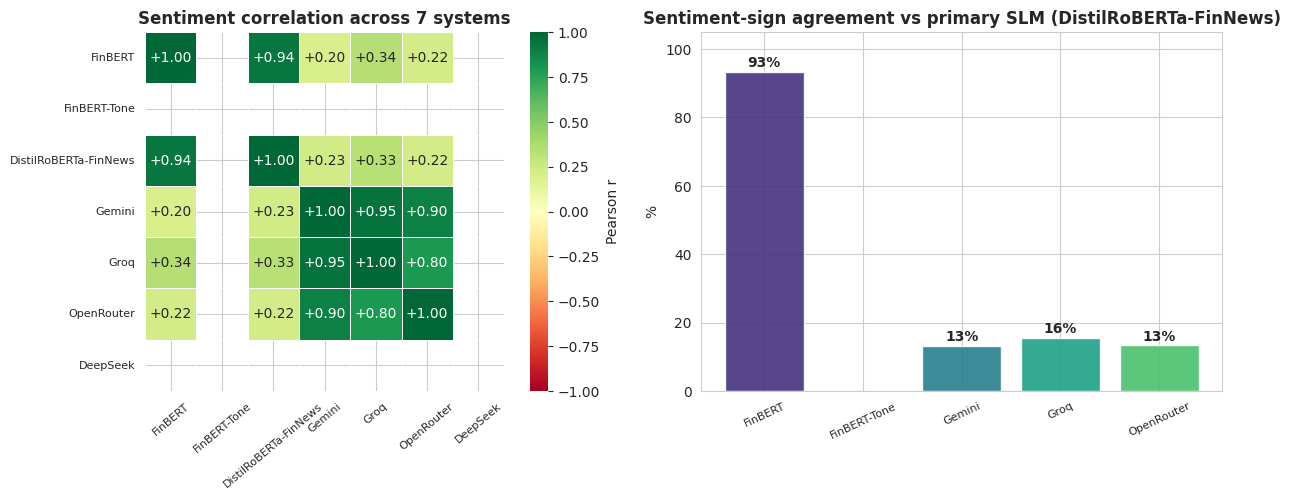

In [21]:
# @title 8e. Comparison chart: correlation heatmap + agreement rates across all systems
if wide_df is not None and len(wide_df) and len(ALL_SYSTEMS) >= 2:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
    sns.heatmap(corr, annot=True, fmt="+.2f", cmap="RdYlGn", vmin=-1, vmax=1,
               square=True, linewidths=.5, ax=ax1, cbar_kws={"label": "Pearson r"})
    ax1.set_title(f"Sentiment correlation across {len(ALL_SYSTEMS)} systems", fontweight="bold")
    ax1.tick_params(axis="x", rotation=40, labelsize=8); ax1.tick_params(axis="y", rotation=0, labelsize=8)

    others = [s for s in ALL_SYSTEMS if s != baseline]
    vals = [agree.loc[baseline, s] for s in others]
    colors = sns.color_palette("viridis", len(others))
    ax2.bar(others, vals, color=colors, alpha=.9)
    for i, v in enumerate(vals):
        ax2.text(i, v + 1.5, f"{v:.0f}%", ha="center", fontsize=10, fontweight="bold")
    ax2.set_ylim(0, 105); ax2.set_ylabel("%")
    ax2.set_title(f"Sentiment-sign agreement vs primary SLM ({baseline})", fontweight="bold")
    ax2.tick_params(axis="x", rotation=25, labelsize=8)
    plt.tight_layout(); plt.show()
else:
    print("Skipped: not enough systems/headlines to chart.")

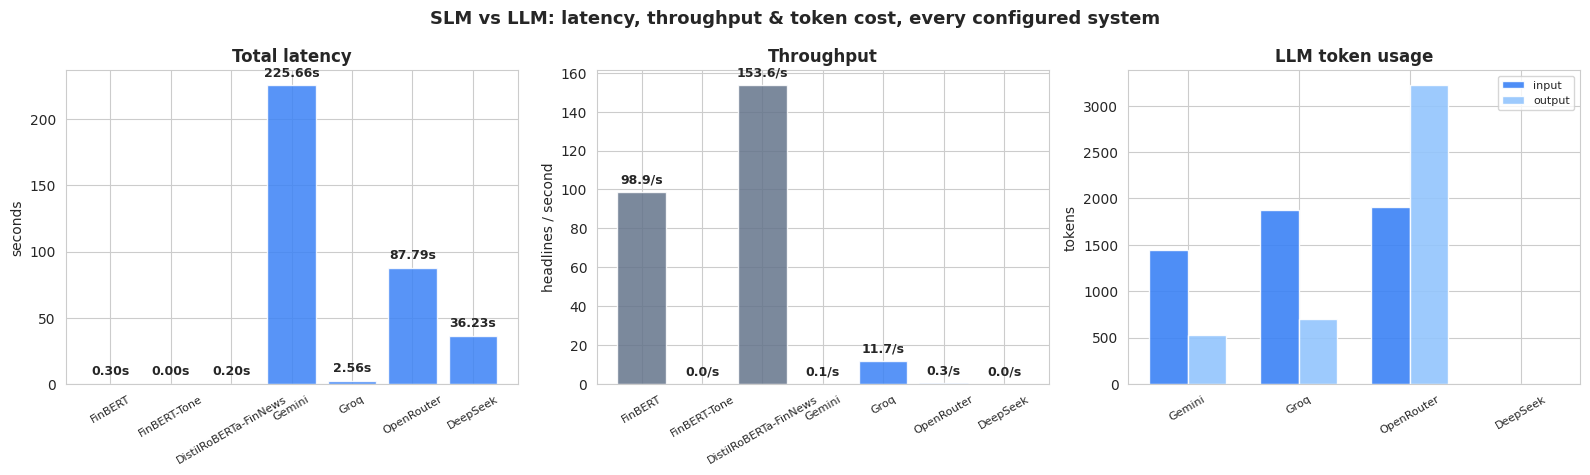

In [22]:
# @title 8f. Metrics comparison chart: latency, throughput & token cost across all systems
if wide_df is not None and len(wide_df) and len(ALL_SYSTEMS) >= 2:
    sys_types = ["SLM" if s in SLM_SENTIMENT_MODELS else "LLM" for s in ALL_SYSTEMS]
    SYS_COLORS = ["#64748b" if ty == "SLM" else "#3b82f6" for ty in sys_types]

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 4.8))
    lat_vals = perf["latency_s"].values
    bars1 = ax1.bar(perf.index, lat_vals, color=SYS_COLORS, alpha=.85)
    for b, v in zip(bars1, lat_vals):
        ax1.text(b.get_x() + b.get_width()/2, v + max(lat_vals.tolist()+[1])*0.03, f"{v:.2f}s", ha="center", fontsize=9, fontweight="bold")
    ax1.set_ylabel("seconds"); ax1.set_title("Total latency", fontweight="bold")
    ax1.tick_params(axis="x", rotation=30, labelsize=8)

    thr_vals = perf["throughput_per_s"].values
    bars2 = ax2.bar(perf.index, thr_vals, color=SYS_COLORS, alpha=.85)
    for b, v in zip(bars2, thr_vals):
        ax2.text(b.get_x() + b.get_width()/2, v + max(thr_vals.tolist()+[1])*0.03, f"{v:.1f}/s", ha="center", fontsize=9, fontweight="bold")
    ax2.set_ylabel("headlines / second"); ax2.set_title("Throughput", fontweight="bold")
    ax2.tick_params(axis="x", rotation=30, labelsize=8)

    llm_perf = perf.loc[[s for s in ALL_SYSTEMS if s in ACTIVE_LLMS]]
    tok_in  = [v if isinstance(v, (int, float)) else 0 for v in llm_perf["input_tokens"]]
    tok_out = [v if isinstance(v, (int, float)) else 0 for v in llm_perf["output_tokens"]]
    if len(llm_perf) and (sum(tok_in) or sum(tok_out)):
        x = np.arange(len(llm_perf)); w = 0.35
        ax3.bar(x - w/2, tok_in,  w, label="input",  color="#3b82f6", alpha=.9)
        ax3.bar(x + w/2, tok_out, w, label="output", color="#93c5fd", alpha=.9)
        ax3.set_xticks(x); ax3.set_xticklabels(llm_perf.index, rotation=30, fontsize=8)
        ax3.set_ylabel("tokens"); ax3.set_title("LLM token usage", fontweight="bold"); ax3.legend(fontsize=8)
    else:
        ax3.text(0.5, 0.5, "No LLM token usage\nto report", ha="center", va="center", transform=ax3.transAxes, fontsize=10, color="#666")
        ax3.set_xticks([]); ax3.set_yticks([]); ax3.set_title("LLM token usage", fontweight="bold")

    plt.suptitle("SLM vs LLM: latency, throughput & token cost, every configured system", fontsize=13, fontweight="bold")
    plt.tight_layout(); plt.show()
else:
    print("Skipped: not enough systems/headlines to chart.")

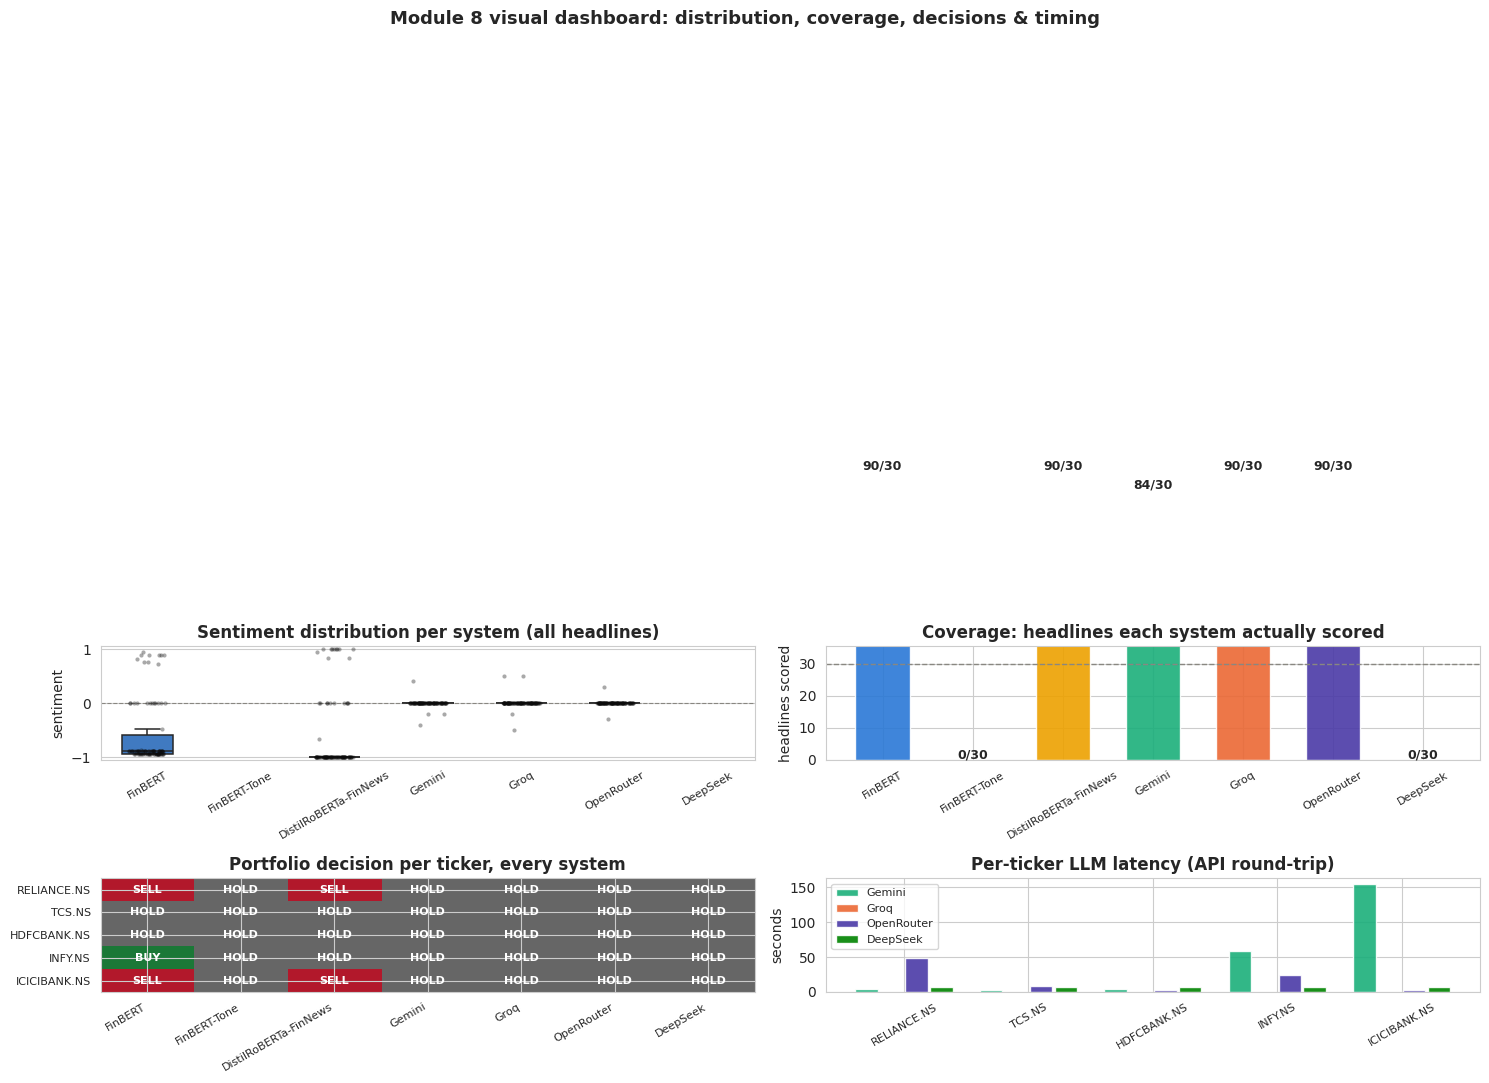

In [23]:
# @title 8g. Extra visual dashboard: sentiment distribution, coverage, decisions & per-ticker timing
if wide_df is not None and len(wide_df) and len(ALL_SYSTEMS) >= 2:
    from matplotlib.colors import ListedColormap

    # Fixed-order, colorblind-checked categorical palette (7 slots -- covers the max of
    # 3 SLMs + 4 possible LLM providers). Red/green are deliberately excluded from this
    # per-system identity palette since they're already reserved elsewhere in this
    # notebook for the BUY/SELL action colors -- reusing them here would blur that meaning.
    _CAT_PALETTE = ["#2a78d6", "#e87ba4", "#eda100", "#1baf7a", "#eb6834", "#4a3aa7", "#008300"]
    SYSTEM_COLORS = {s: _CAT_PALETTE[i % len(_CAT_PALETTE)] for i, s in enumerate(ALL_SYSTEMS)}

    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 11))

    # Panel 1: sentiment distribution per system, pooled across every headline -- shows
    # each system's overall bias/spread, not just its correlation with one baseline.
    sent_long = (wide_df[[f"{s}_sentiment" for s in ALL_SYSTEMS]]
                 .melt(var_name="system", value_name="sentiment").dropna())
    sent_long["system"] = sent_long["system"].str.replace("_sentiment", "", regex=False)
    sns.boxplot(data=sent_long, x="system", y="sentiment", order=ALL_SYSTEMS,
                hue="system", palette=SYSTEM_COLORS, legend=False, width=.55,
                fliersize=0, linewidth=1.1, ax=ax1)
    sns.stripplot(data=sent_long, x="system", y="sentiment", order=ALL_SYSTEMS,
                  color="#0b0b0b", size=3, alpha=.35, jitter=.2, ax=ax1)
    ax1.axhline(0, color="#898781", lw=.8, ls="--")
    ax1.set_ylim(-1.05, 1.05); ax1.set_xlabel(""); ax1.set_ylabel("sentiment")
    ax1.set_title("Sentiment distribution per system (all headlines)", fontweight="bold")
    ax1.tick_params(axis="x", rotation=30, labelsize=8)

    # Panel 2: coverage -- how many of the live headlines each system actually returned a
    # usable score for (an LLM whose JSON failed to parse for some headlines shows here).
    total_heads = sum(len(v) for v in NEWS_BANK.values())
    covered = [wide_df[f"{s}_sentiment"].notna().sum() for s in ALL_SYSTEMS]
    bars2 = ax2.bar(ALL_SYSTEMS, covered, color=[SYSTEM_COLORS[s] for s in ALL_SYSTEMS], alpha=.9, width=.6)
    for b, v in zip(bars2, covered):
        ax2.text(b.get_x() + b.get_width()/2, v + total_heads*0.02, f"{v}/{total_heads}",
                  ha="center", fontsize=9, fontweight="bold")
    ax2.axhline(total_heads, color="#898781", lw=1, ls="--")
    ax2.set_ylim(0, total_heads * 1.18); ax2.set_ylabel("headlines scored")
    ax2.set_title("Coverage: headlines each system actually scored", fontweight="bold")
    ax2.tick_params(axis="x", rotation=30, labelsize=8)

    # Panel 3: portfolio decision (BUY/HOLD/SELL) per ticker per system -- the same
    # green/red/gray action colors used everywhere else in this notebook (T1, G1, G3,
    # the recommendation cards), applied here as a status grid rather than a new palette.
    action_code = {"SELL": -1, "HOLD": 0, "BUY": 1}
    mat = np.array([[action_code[decisions.loc[t, f"{s}_action"]] for s in ALL_SYSTEMS] for t in TICKERS])
    ax3.imshow(mat, cmap=ListedColormap(["#b2182b", "#666666", "#1b7837"]), vmin=-1, vmax=1, aspect="auto")
    ax3.set_xticks(range(len(ALL_SYSTEMS))); ax3.set_xticklabels(ALL_SYSTEMS, rotation=30, ha="right", fontsize=8)
    ax3.set_yticks(range(len(TICKERS))); ax3.set_yticklabels(TICKERS, fontsize=8)
    for i, t in enumerate(TICKERS):
        for j, s in enumerate(ALL_SYSTEMS):
            ax3.text(j, i, decisions.loc[t, f"{s}_action"], ha="center", va="center",
                     fontsize=8, color="white", fontweight="bold")
    ax3.set_title("Portfolio decision per ticker, every system", fontweight="bold")

    # Panel 4: per-ticker LLM latency -- total latency is in 8f, this shows whether any
    # one stock's API round-trip is an outlier rather than just the summed total.
    if ACTIVE_LLMS:
        x = np.arange(len(TICKERS)); w = 0.8 / len(ACTIVE_LLMS)
        for i, name in enumerate(ACTIVE_LLMS):
            vals = [LLM_LATENCY[name].get(t, 0) for t in TICKERS]
            ax4.bar(x + i*w - 0.4 + w/2, vals, width=w*.9, label=name, color=SYSTEM_COLORS[name], alpha=.9)
        ax4.set_xticks(x); ax4.set_xticklabels(TICKERS, rotation=30, fontsize=8)
        ax4.set_ylabel("seconds"); ax4.legend(fontsize=8)
        ax4.set_title("Per-ticker LLM latency (API round-trip)", fontweight="bold")
    else:
        ax4.text(0.5, 0.5, "No LLMs configured", ha="center", va="center", transform=ax4.transAxes, fontsize=10, color="#666")
        ax4.set_xticks([]); ax4.set_yticks([]); ax4.set_title("Per-ticker LLM latency", fontweight="bold")

    plt.suptitle("Module 8 visual dashboard: distribution, coverage, decisions & timing", fontsize=13, fontweight="bold")
    plt.tight_layout(); plt.show()
else:
    print("Skipped: not enough systems/headlines to chart.")

## Notes & extensions
- **Live news:** Module 4 pulls REAL, live headlines only (Google News RSS, or NewsAPI.org if `NEWSAPI_KEY` is set) — there is no synthetic/fabricated fallback anywhere. If real headlines can't be found for a stock after retrying across sources, query variants and time windows, the cell raises an error and stops rather than guessing.
- **Timestamps & sources:** every headline-level table carries the article's own publish time (`published`, not fetch time) and outlet (`source`), so results are traceable to a real, dated article.
- **SLM vs LLM:** Module 8 scores the same live headlines with 3 local SLMs (FinBERT, FinBERT-Tone, DistilRoBERTa-FinNews) and up to 3 free LLM APIs (Gemini, Groq, OpenRouter), plus an optional paid DeepSeek key — and evaluates pairwise agreement, correlation, portfolio-decision impact, latency and token cost across every system that's configured.
- **Gemini 429 errors:** fixed the underlying bug (the old code called a non-existent SDK method and left "thinking" mode on, burning token quota on hidden reasoning). If your key still hits the free-tier quota, add a second/third key (a different Google account) as `GEMINI_API_KEY_2` / `GEMINI_API_KEY_3` Colab secrets — Module 8 rotates to the next key automatically rather than failing.
- **Swap or add an LLM:** every provider is a `call_*_batch(ticker, headlines)` function in cell 8b returning `(scores, elapsed_s, usage)` — add a new one and register it in `LLM_CALLERS` / `LLM_INFO` (cell 8a) to plug in another API.
- **Swap the primary SLM:** change `PRIMARY_SLM` in the "2+3" cell to any key in `SLM_SENTIMENT_MODELS`.
- **Regional language:** add `ai4bharat/IndicBERT` for Hindi/regional headlines and merge scores.
- **Stronger backtest:** align *historical* sentiment with prices for a true multi-source backtest, add transaction costs and Sharpe/max-drawdown.
- **Persistence:** `feedback.json` already persists ratings; mount Google Drive to keep them across sessions.

> Educational use only — not investment advice.